# Predicting Pile Bearing Capacity using MLP

This notebook demonstrates **function approximation** using a Multi-Layer Perceptron (MLP) in PyTorch. We'll predict pile bearing capacity from geotechnical features.

**Goal**: Learn the nonlinear mapping from pile geometry and soil properties → bearing capacity

**Note**: For detailed MLP concepts (activation functions, architectures, etc.), see `00b-mlp-classification.ipynb`

**Exercise:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/ai-geotech/blob/main/docs/00-mlp-dtree/00c-mlp-pile-capacity-exercise.ipynb)
**Solution:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/ai-geotech/blob/main/docs/00-mlp-dtree/00c-mlp-pile-capacity.ipynb)

## Input Features

This dataset contains measurements from 100 pile load tests in Vietnam. We'll use 10 geotechnical features to predict pile bearing capacity:

### Pile Geometry:
- **Pile_Diameter** (m): Cross-sectional diameter (0.3-0.4 m)
- **Tip_Length** (m): Length of bottom segment (3.4-5.7 m)
- **Middle_Length** (m): Length of middle segment (1.5-8.0 m)
- **Top_Length** (m): Length of top segment (0-1.69 m)

### Elevations:
- **Ground_Elev** (m): Natural ground surface (0.68-3.4 m)
- **Pile_Top_Elev** (m): Pile head elevation (3.04-4.12 m)
- **Guide_Stop_Elev** (m): Guide stop elevation (1.03-4.35 m)
- **Pile_Tip_Elev** (m): Pile tip depth (**most important**, 8.3-16.09 m)

### Soil Strength:
- **SPT_Embedded**: Average SPT N-value along embedded length (5.6-15.41)
- **SPT_Tip**: Average SPT N-value at pile tip (4.38-7.75)

### Target:
- **Bearing_Capacity** (MN): Measured axial capacity (0.407-1.551 MN)

**Reference**: *Prediction of axial load capacity of PHC nodular pile using Bayesian regularization artificial neural network* (PLOS ONE, 2022)

## 1. Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


## 2. Load and Prepare Data

In [18]:
!wget https://raw.githubusercontent.com/kks32-courses/ai-geotech/refs/heads/main/docs/00-mlp-dtree/pile_bearing_capacity.csv

--2025-11-06 07:20:41--  https://raw.githubusercontent.com/kks32-courses/ai-geotech/refs/heads/main/docs/00-mlp-dtree/pile_bearing_capacity.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 108324 (106K) [text/plain]
Saving to: ‘pile_bearing_capacity.csv.5’

pile_bearing_capaci 100%[===================>] 105.79K  --.-KB/s    in 0.1s    

2025-11-06 07:20:41 (793 KB/s) - ‘pile_bearing_capacity.csv.5’ saved [108324/108324]



In [19]:
# Load the dataset
df = pd.read_csv('pile_bearing_capacity.csv')

# Define meaningful column names mapping
column_mapping = {
    'X1': 'Pile_Diameter',
    'X2': 'Tip_Length',
    'X3': 'Middle_Length',
    'X4': 'Top_Length',
    'X5': 'Ground_Elev',
    'X6': 'Pile_Top_Elev',
    'X7': 'Guide_Stop_Elev',
    'X8': 'Pile_Tip_Elev',
    'X9': 'SPT_Embedded',
    'X10': 'SPT_Tip',
    'Pu_Experiment': 'Bearing_Capacity'
}

# Rename columns
df = df.rename(columns=column_mapping)

# Select features and target
feature_columns = ['Pile_Diameter', 'Tip_Length', 'Middle_Length', 'Top_Length',
                   'Ground_Elev', 'Pile_Top_Elev', 'Guide_Stop_Elev', 'Pile_Tip_Elev',
                   'SPT_Embedded', 'SPT_Tip']
target_column = 'Bearing_Capacity'

# Create feature matrix X and target vector y
X = df[feature_columns].values
y = df[target_column].values.reshape(-1, 1)  # Reshape for PyTorch

print(f"Dataset shape: {df.shape}")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFirst 5 samples:")
df[feature_columns + [target_column]].head()

Dataset shape: (100, 66)
Features shape: (100, 10)
Target shape: (100, 1)

First 5 samples:


,Pile_Diameter,Tip_Length,Middle_Length,Top_Length,Ground_Elev,Pile_Top_Elev,Guide_Stop_Elev,Pile_Tip_Elev,SPT_Embedded,SPT_Tip,Bearing_Capacity
0,0.4,4.35,8.00,1.0,2.05,3.48,2.08,15.40,13.35,7.631086,1.3950
1,0.3,3.40,5.25,0.0,3.40,3.47,3.42,12.05,8.65,6.750000,0.5598
2,0.3,3.40,5.30,0.0,3.40,3.52,3.42,12.10,8.70,6.760000,0.5089
3,0.4,4.25,8.00,0.9,2.15,3.56,2.26,15.30,13.15,7.610000,1.3950
4,0.4,3.40,7.30,0.0,3.40,3.49,3.39,14.10,10.70,7.280000,1.0688


In [20]:
# Summary statistics
print("Summary Statistics:")
print("="*80)
print()
df.describe()

Summary Statistics:



,Pile_Diameter,Tip_Length,Middle_Length,Top_Length,Ground_Elev,Pile_Top_Elev,Guide_Stop_Elev,Pile_Tip_Elev,SPT_Embedded,SPT_Tip,...,Est 45,Est 46,Est 47,Est 48,Est 49,Est 50,Est 51,Est 52,Pu_Prediction,R_square
count,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000
mean,0.365000,3.869500,6.65720,0.340500,2.766000,3.500700,2.901400,13.625700,10.897200,7.065517,...,0.864408,0.885571,0.906687,0.927751,0.941797,0.962861,0.983935,0.997949,1.011989,0.972895
std,0.047937,0.498325,1.57255,0.457011,0.618849,0.072756,0.620904,1.738287,2.245025,0.639656,...,0.297529,0.304880,0.312201,0.319477,0.324331,0.331648,0.338988,0.343829,0.348698,NaN
min,0.300000,3.400000,1.71000,0.000000,1.950000,3.260000,1.060000,8.510000,5.810000,4.560000,...,0.407977,0.418143,0.428011,0.438058,0.445126,0.454570,0.465096,0.471374,0.477652,0.972895
25%,0.300000,3.400000,5.25000,0.000000,2.050000,3.450000,2.150000,12.050000,8.650000,6.750000,...,0.518414,0.530984,0.543667,0.556390,0.564784,0.577489,0.590184,0.598439,0.606945,0.972895
50%,0.400000,3.650000,7.30000,0.000000,2.950000,3.490000,3.320000,14.100000,11.275000,7.180000,...,0.983637,1.007343,1.031401,1.055372,1.071283,1.095200,1.119108,1.134821,1.150841,0.972895
75%,0.400000,4.350000,8.00000,0.902500,3.400000,3.550000,3.420000,15.302500,13.250000,7.603383,...,1.136467,1.163793,1.191892,1.219320,1.237848,1.265585,1.293557,1.311900,1.330036,0.972895
max,0.400000,5.400000,8.00000,1.220000,3.400000,3.700000,3.680000,15.620000,14.700000,7.750000,...,1.262972,1.294144,1.324815,1.355427,1.375802,1.406726,1.437235,1.457904,1.478354,0.972895


## 3. Three-Way Data Split: Train / Validation / Test

We'll split the data into three sets:
- **Training Set (70%)**: Used to train the model (update weights)
- **Validation Set (15%)**: Used to monitor performance during training and tune hyperparameters
- **Testing Set (15%)**: Final evaluation on completely unseen data

This approach prevents overfitting and gives us an unbiased estimate of model performance.

In [21]:
# First split: separate test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Second split: separate train and validation from remaining data
# 70% of original data for training, 15% for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42  # 0.176 * 0.85 ≈ 0.15
)

print("Data Split Summary:")
print("="*80)
print(f"Total samples:      {len(X)}")
print(f"Training samples:   {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation samples: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Testing samples:    {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nTraining set - Target statistics:")
print(f"  Mean: {y_train.mean():.4f} MN, Std: {y_train.std():.4f} MN")
print(f"Validation set - Target statistics:")
print(f"  Mean: {y_val.mean():.4f} MN, Std: {y_val.std():.4f} MN")
print(f"Testing set - Target statistics:")
print(f"  Mean: {y_test.mean():.4f} MN, Std: {y_test.std():.4f} MN")

Data Split Summary:
Total samples:      100
Training samples:   70 (70.0%)
Validation samples: 15 (15.0%)
Testing samples:    15 (15.0%)

Training set - Target statistics:
  Mean: 1.0399 MN, Std: 0.3596 MN
Validation set - Target statistics:
  Mean: 0.9196 MN, Std: 0.3374 MN
Testing set - Target statistics:
  Mean: 1.0100 MN, Std: 0.3709 MN


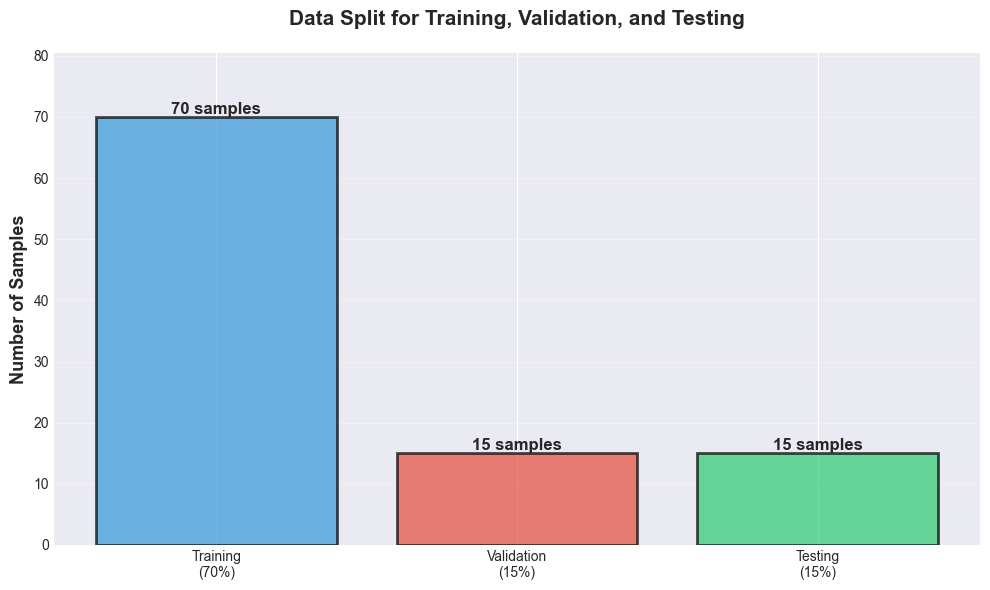

In [22]:
# Visualize the data split
fig, ax = plt.subplots(figsize=(10, 6))

splits = ['Training\n(70%)', 'Validation\n(15%)', 'Testing\n(15%)']
sizes = [len(X_train), len(X_val), len(X_test)]
colors = ['#3498db', '#e74c3c', '#2ecc71']

bars = ax.bar(splits, sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, size in zip(bars, sizes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{size} samples',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Number of Samples', fontsize=13, fontweight='bold')
ax.set_title('Data Split for Training, Validation, and Testing', fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(sizes) * 1.15)

plt.tight_layout()
plt.show()

## 4. Feature Scaling

Neural networks perform better when features are normalized to similar scales.

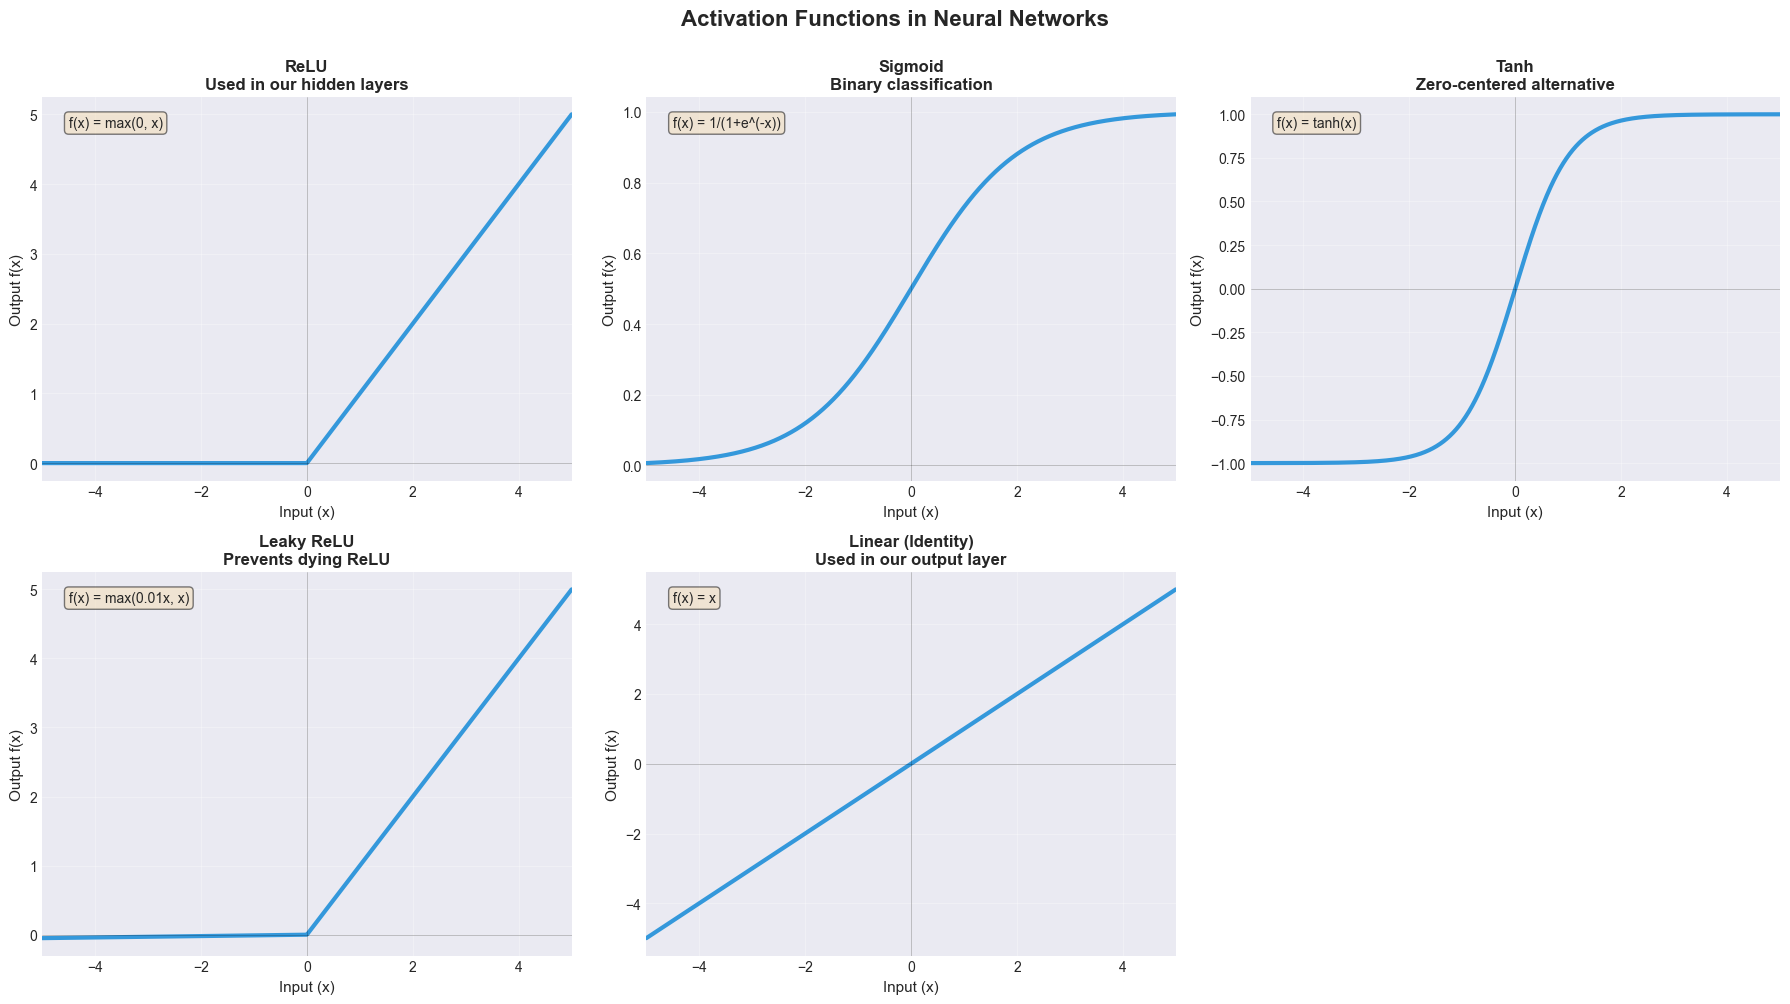

Our MLP Architecture will use:
  - ReLU activation in hidden layers (non-linear, prevents vanishing gradients)
  - Linear (Identity) activation in output layer (regression task)


In [26]:
# Visualize activation functions
x = np.linspace(-5, 5, 1000)

# Define activation functions
relu = lambda x: np.maximum(0, x)
sigmoid = lambda x: 1 / (1 + np.exp(-x))
tanh = lambda x: np.tanh(x)
leaky_relu = lambda x: np.where(x > 0, x, 0.01 * x)
linear = lambda x: x

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

activations = [
    (relu, 'ReLU', 'Used in our hidden layers'),
    (sigmoid, 'Sigmoid', 'Binary classification'),
    (tanh, 'Tanh', 'Zero-centered alternative'),
    (leaky_relu, 'Leaky ReLU', 'Prevents dying ReLU'),
    (linear, 'Linear (Identity)', 'Used in our output layer'),
]

for idx, (func, name, desc) in enumerate(activations):
    y = func(x)
    axes[idx].plot(x, y, linewidth=3, color='#3498db')
    axes[idx].axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    axes[idx].axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlabel('Input (x)', fontsize=11)
    axes[idx].set_ylabel('Output f(x)', fontsize=11)
    axes[idx].set_title(f'{name}\n{desc}', fontsize=12, fontweight='bold')
    axes[idx].set_xlim(-5, 5)
    
    # Add formula
    if name == 'ReLU':
        formula = 'f(x) = max(0, x)'
    elif name == 'Sigmoid':
        formula = 'f(x) = 1/(1+e^(-x))'
    elif name == 'Tanh':
        formula = 'f(x) = tanh(x)'
    elif name == 'Leaky ReLU':
        formula = 'f(x) = max(0.01x, x)'
    else:
        formula = 'f(x) = x'
    
    axes[idx].text(0.05, 0.95, formula, transform=axes[idx].transAxes,
                  fontsize=10, verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Remove the last unused subplot
fig.delaxes(axes[5])

plt.suptitle('Activation Functions in Neural Networks', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Our MLP Architecture will use:")
print("  - ReLU activation in hidden layers (non-linear, prevents vanishing gradients)")
print("  - Linear (Identity) activation in output layer (regression task)")

In [23]:
# Feature scaling - Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling applied successfully!")
print(f"\nScaled training data - Feature means (should be ~0):")
print(f"  {X_train_scaled.mean(axis=0)}")
print(f"\nScaled training data - Feature stds (should be ~1):")
print(f"  {X_train_scaled.std(axis=0)}")

Scaling applied successfully!

Scaled training data - Feature means (should be ~0):
  [ 8.56457762e-16  3.38459419e-15  1.58603289e-16  2.22044605e-17
 -2.91195639e-15 -3.42424501e-15  2.14431647e-15 -8.53285696e-16
 -7.04198604e-16 -5.02772427e-16]

Scaled training data - Feature stds (should be ~1):
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Convert to PyTorch Tensors

In [24]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)

X_val_tensor = torch.FloatTensor(X_val_scaled).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)

X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

print("PyTorch tensors created:")
print(f"X_train shape: {X_train_tensor.shape}, dtype: {X_train_tensor.dtype}, device: {X_train_tensor.device}")
print(f"y_train shape: {y_train_tensor.shape}, dtype: {y_train_tensor.dtype}, device: {y_train_tensor.device}")
print(f"X_val shape:   {X_val_tensor.shape}, dtype: {X_val_tensor.dtype}, device: {X_val_tensor.device}")
print(f"X_test shape:  {X_test_tensor.shape}, dtype: {X_test_tensor.dtype}, device: {X_test_tensor.device}")

PyTorch tensors created:
X_train shape: torch.Size([70, 10]), dtype: torch.float32, device: cpu
y_train shape: torch.Size([70, 1]), dtype: torch.float32, device: cpu
X_val shape:   torch.Size([15, 10]), dtype: torch.float32, device: cpu
X_test shape:  torch.Size([15, 10]), dtype: torch.float32, device: cpu


In [25]:
# Create DataLoaders for batch processing

# Set batch size
batch_size = 16

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders created with batch_size={batch_size}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Testing batches: {len(test_loader)}")

DataLoaders created with batch_size=16
Training batches: 5
Validation batches: 1
Testing batches: 1


In [27]:
class PileBearingCapacityMLP(nn.Module):
    """
    Multi-Layer Perceptron for Pile Bearing Capacity Prediction
    
    Architecture:
    - Input: 10 features
    - Hidden 1: 64 neurons (ReLU + Dropout 0.2)
    - Hidden 2: 32 neurons (ReLU + Dropout 0.2)
    - Hidden 3: 16 neurons (ReLU + Dropout 0.1)
    - Output: 1 neuron (Linear)
    """
    def __init__(self, input_size=10, hidden_sizes=[64, 32, 16], dropout_rates=[0.2, 0.2, 0.1]):
        super(PileBearingCapacityMLP, self).__init__()
        
        # Layer 1: Input -> Hidden 1
        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rates[0])
        
        # Layer 2: Hidden 1 -> Hidden 2
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rates[1])
        
        # Layer 3: Hidden 2 -> Hidden 3
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout_rates[2])
        
        # Output Layer: Hidden 3 -> Output
        self.fc4 = nn.Linear(hidden_sizes[2], 1)
        # No activation function here (linear output for regression)
        
    def forward(self, x):
        # Forward pass through the network
        x = self.fc1(x)      # Linear transformation
        x = self.relu1(x)    # ReLU activation
        x = self.dropout1(x) # Dropout regularization
        
        x = self.fc2(x)      # Linear transformation
        x = self.relu2(x)    # ReLU activation
        x = self.dropout2(x) # Dropout regularization
        
        x = self.fc3(x)      # Linear transformation
        x = self.relu3(x)    # ReLU activation
        x = self.dropout3(x) # Dropout regularization
        
        x = self.fc4(x)      # Output layer (linear)
        
        return x
    
    def count_parameters(self):
        """Count total trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# Create the model
model = PileBearingCapacityMLP(
    input_size=10,
    hidden_sizes=[64, 32, 16],
    dropout_rates=[0.2, 0.2, 0.1]
).to(device)

# Print model architecture
print("="*80)
print("MLP Architecture Summary")
print("="*80)
print(model)
print("="*80)
print(f"Total trainable parameters: {model.count_parameters():,}")
print("="*80)

# Print layer-by-layer details
print("\nLayer Details:")
print("-"*80)
for name, param in model.named_parameters():
    print(f"{name:20s} | Shape: {str(param.shape):20s} | Parameters: {param.numel():,}")
print("-"*80)

MLP Architecture Summary
PileBearingCapacityMLP(
  (fc1): Linear(in_features=10, out_features=64, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (relu3): ReLU()
  (dropout3): Dropout(p=0.1, inplace=False)
  (fc4): Linear(in_features=16, out_features=1, bias=True)
)
Total trainable parameters: 3,329

Layer Details:
--------------------------------------------------------------------------------
fc1.weight           | Shape: torch.Size([64, 10]) | Parameters: 640
fc1.bias             | Shape: torch.Size([64])     | Parameters: 64
fc2.weight           | Shape: torch.Size([32, 64]) | Parameters: 2,048
fc2.bias             | Shape: torch.Size([32])     | Parameters: 32
fc3.weight           | Shape: torch.Size([16, 32]) | Parameters: 512
fc3.bias             | Shape: torch.Size([16])  

## 7. Define Loss Function and Optimizer

For regression tasks:
- **Loss Function**: Mean Squared Error (MSE)
- **Optimizer**: Adam (Adaptive Moment Estimation)

In [28]:
# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)

# Training and validation functions
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train the model for one epoch"""
    model.train()
    running_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * batch_X.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    return epoch_loss

def validate_epoch(model, val_loader, criterion, device):
    """Validate the model for one epoch"""
    model.eval()
    running_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            running_loss += loss.item() * batch_X.size(0)
    
    epoch_loss = running_loss / len(val_loader.dataset)
    return epoch_loss

print("Loss function, optimizer, and scheduler configured.")
print(f"Criterion: MSE Loss")
print(f"Optimizer: Adam (lr=0.001, weight_decay=1e-5)")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=20)")

Loss function, optimizer, and scheduler configured.
Criterion: MSE Loss
Optimizer: Adam (lr=0.001, weight_decay=1e-5)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=20)


In [29]:
# Training configuration
num_epochs = 500
patience = 50  # Early stopping patience

best_val_loss = float('inf')
epochs_without_improvement = 0

# Lists to store losses
train_losses = []
val_losses = []

print("Starting training...")
print("="*80)

# Training loop
for epoch in range(num_epochs):
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    
    # Validate
    val_loss = validate_epoch(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    
    # Learning rate scheduler step
    scheduler.step(val_loss)
    
    # Print progress every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] | "
              f"Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        epochs_without_improvement += 1
    
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        print(f"Best validation loss: {best_val_loss:.6f}")
        break

print("="*80)
print("Training completed!")
print(f"Final train loss: {train_losses[-1]:.6f}")
print(f"Final val loss: {val_losses[-1]:.6f}")
print(f"Best val loss: {best_val_loss:.6f}")

# Load best model
model.load_state_dict(torch.load('best_model.pth'))
print("\nLoaded best model weights.")

Starting training...
Epoch [ 50/500] | Train Loss: 0.051503 | Val Loss: 0.030157 | LR: 0.001000
Epoch [100/500] | Train Loss: 0.036207 | Val Loss: 0.016283 | LR: 0.001000
Epoch [150/500] | Train Loss: 0.027130 | Val Loss: 0.012858 | LR: 0.000500

Early stopping triggered at epoch 187
Best validation loss: 0.011306
Training completed!
Final train loss: 0.026037
Final val loss: 0.014040
Best val loss: 0.011306

Loaded best model weights.


## 8. Training Loop with Validation Monitoring

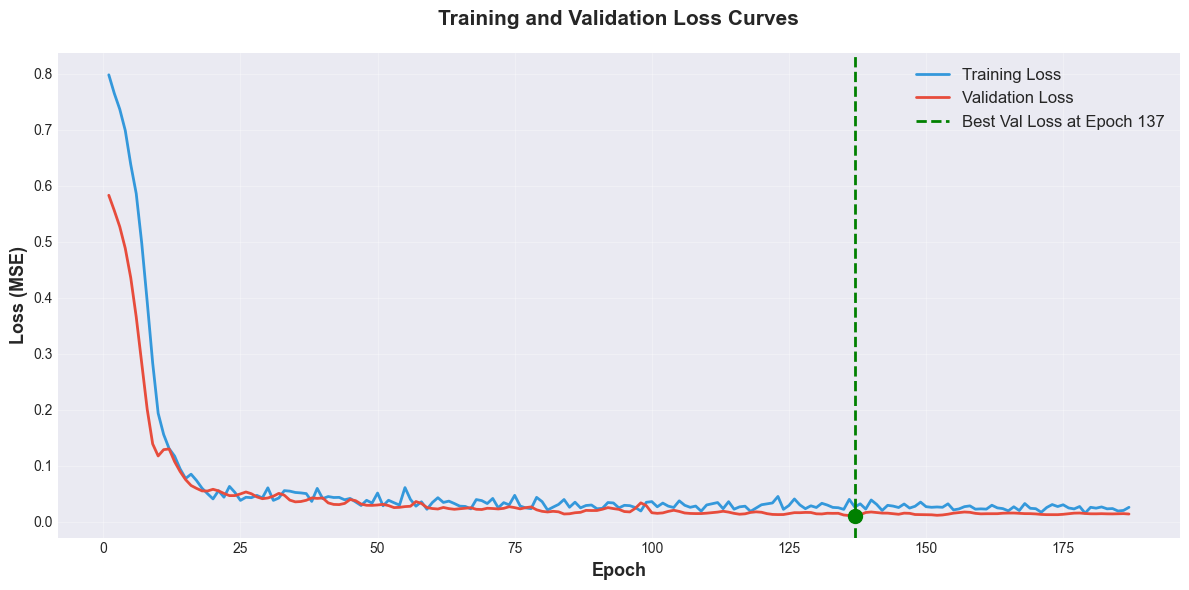

Best validation loss: 0.011306 at epoch 137
Final training loss: 0.026037
Final validation loss: 0.014040

Model Evaluation Metrics

Training Set:
  R² Score: 0.897057
  RMSE: 0.115386 MN
  MAE: 0.087135 MN
  MAPE: 7.65%

Validation Set:
  R² Score: 0.900698
  RMSE: 0.106330 MN
  MAE: 0.082133 MN
  MAPE: 10.16%

Test Set:
  R² Score: 0.847207
  RMSE: 0.144970 MN
  MAE: 0.115797 MN
  MAPE: 12.97%


In [30]:
# Plot training and validation loss
fig, ax = plt.subplots(figsize=(12, 6))

epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, label='Training Loss', linewidth=2, color='#3498db')
ax.plot(epochs_range, val_losses, label='Validation Loss', linewidth=2, color='#e74c3c')

# Mark best validation loss
best_epoch = val_losses.index(min(val_losses)) + 1
ax.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, 
           label=f'Best Val Loss at Epoch {best_epoch}')
ax.scatter(best_epoch, min(val_losses), color='green', s=100, zorder=5)

ax.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax.set_ylabel('Loss (MSE)', fontsize=13, fontweight='bold')
ax.set_title('Training and Validation Loss Curves', fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best validation loss: {min(val_losses):.6f} at epoch {best_epoch}")
print(f"Final training loss: {train_losses[-1]:.6f}")
print(f"Final validation loss: {val_losses[-1]:.6f}")

# Compute predictions and evaluation metrics for all datasets
model.eval()
with torch.no_grad():
    # Training set predictions
    y_train_pred_tensor = model(X_train_tensor)
    y_train_pred = y_train_pred_tensor.cpu().numpy()
    y_train_true = y_train
    
    # Validation set predictions
    y_val_pred_tensor = model(X_val_tensor)
    y_val_pred = y_val_pred_tensor.cpu().numpy()
    y_val_true = y_val
    
    # Test set predictions
    y_test_pred_tensor = model(X_test_tensor)
    y_test_pred = y_test_pred_tensor.cpu().numpy()
    y_test_true = y_test

# Calculate metrics for all datasets
# Training metrics
train_r2 = r2_score(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_mape = np.mean(np.abs((y_train_true - y_train_pred) / y_train_true)) * 100

# Validation metrics
val_r2 = r2_score(y_val_true, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
val_mae = mean_absolute_error(y_val_true, y_val_pred)
val_mape = np.mean(np.abs((y_val_true - y_val_pred) / y_val_true)) * 100

# Test metrics
test_r2 = r2_score(y_test_true, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
test_mae = mean_absolute_error(y_test_true, y_test_pred)
test_mape = np.mean(np.abs((y_test_true - y_test_pred) / y_test_true)) * 100

print("\n" + "="*80)
print("Model Evaluation Metrics")
print("="*80)
print(f"\nTraining Set:")
print(f"  R² Score: {train_r2:.6f}")
print(f"  RMSE: {train_rmse:.6f} MN")
print(f"  MAE: {train_mae:.6f} MN")
print(f"  MAPE: {train_mape:.2f}%")

print(f"\nValidation Set:")
print(f"  R² Score: {val_r2:.6f}")
print(f"  RMSE: {val_rmse:.6f} MN")
print(f"  MAE: {val_mae:.6f} MN")
print(f"  MAPE: {val_mape:.2f}%")

print(f"\nTest Set:")
print(f"  R² Score: {test_r2:.6f}")
print(f"  RMSE: {test_rmse:.6f} MN")
print(f"  MAE: {test_mae:.6f} MN")
print(f"  MAPE: {test_mape:.2f}%")
print("="*80)

## 9. Visualize Training Progress

In [31]:
# Create summary table
results_summary = pd.DataFrame({
    'Dataset': ['Training', 'Validation', 'Testing'],
    'Samples': [len(y_train_true), len(y_val_true), len(y_test_true)],
    'R² Score': [train_r2, val_r2, test_r2],
    'RMSE (MN)': [train_rmse, val_rmse, test_rmse],
    'MAE (MN)': [train_mae, val_mae, test_mae],
    'MAPE (%)': [train_mape, val_mape, test_mape]
})

print("\nResults Summary Table:")
print("="*100)
print(results_summary.to_string(index=False))
print("="*100)


Results Summary Table:
   Dataset  Samples  R² Score  RMSE (MN)  MAE (MN)  MAPE (%)
  Training       70  0.897057   0.115386  0.087135  7.645918
Validation       15  0.900698   0.106330  0.082133 10.158880
   Testing       15  0.847207   0.144970  0.115797 12.967026


## 10. Model Evaluation

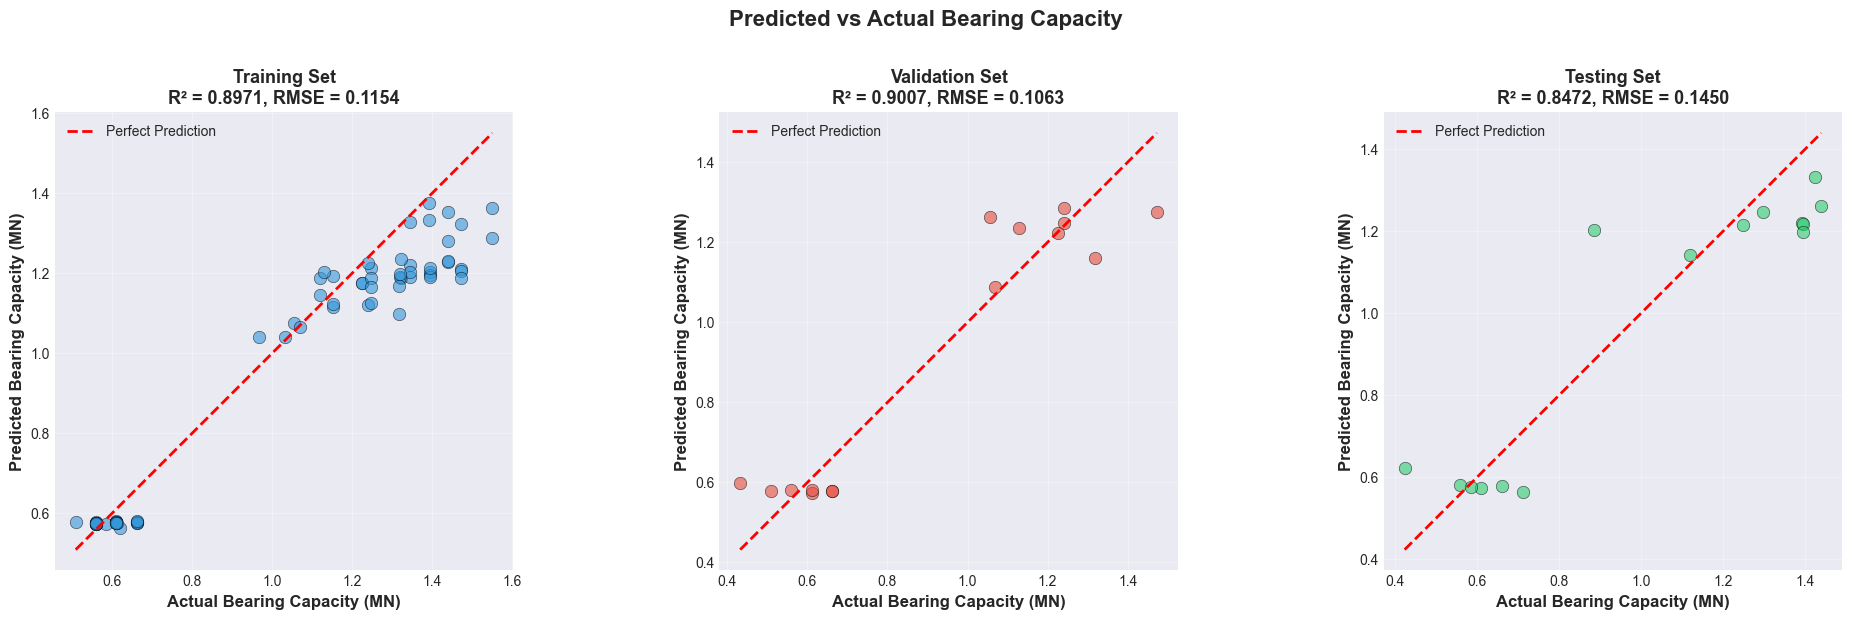

In [32]:
# Predicted vs Actual for all three sets
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

datasets_plot = [
    (y_train_true, y_train_pred, 'Training', train_r2, train_rmse, '#3498db'),
    (y_val_true, y_val_pred, 'Validation', val_r2, val_rmse, '#e74c3c'),
    (y_test_true, y_test_pred, 'Testing', test_r2, test_rmse, '#2ecc71')
]

for idx, (y_true, y_pred, name, r2, rmse, color) in enumerate(datasets_plot):
    axes[idx].scatter(y_true, y_pred, alpha=0.6, s=80, edgecolors='black', 
                     linewidths=0.5, color=color)
    
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 
                  'r--', lw=2, label='Perfect Prediction')
    
    axes[idx].set_xlabel('Actual Bearing Capacity (MN)', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Predicted Bearing Capacity (MN)', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{name} Set\nR² = {r2:.4f}, RMSE = {rmse:.4f}', 
                       fontsize=13, fontweight='bold')
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_aspect('equal', adjustable='box')

plt.suptitle('Predicted vs Actual Bearing Capacity', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()